In [1]:
import numpy as np
import pandas as pd
import os
import math
import re
import random
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

In [2]:
#collect data - metadata
data = []
data_dir = "20_newsgroups"
classes = os.listdir(data_dir)
for folder in classes:
    folder_path = f"{data_dir}/{folder}"
    if(os.path.exists(folder_path)):
        files = os.listdir(folder_path)
        #print(len(files), folder_path)
        for file in files:
            file_path = f"{folder_path}/{file}"
            with open(file_path, "r", encoding="utf-8", errors="ignore" ) as f:
                text = f.read()
                data.append({"label": folder, "text": text})

In [3]:
## feature engineering - clean data
def clean_text(data):
    if not data:
        return []
    data = data.lower()
    data = re.sub(r'[^\w\s]', ' ', data)
    data = re.sub(r'\d+', ' ', data)
    data = re.sub(r'\s+', ' ', data).strip()
    token = data.split()
    token = [t for t in token if len(t) > 2]
    
    corpus_text = " ".join(token)
    return corpus_text, len(token)

#Count terms frequency for each document
def term_frequency(data):
    dictionary = dict.fromkeys(set(data), 0)
    for token in data:
        dictionary[token] +=1
    return dictionary

max_features = 0

for data_point in data:
    tokens, length = clean_text(data_point["text"])
    max_features = max(length, max_features)
    data_point["corpus_text"] = tokens

corpus = [dp["corpus_text"] for dp in data]
X = TfidfVectorizer(max_features=max_features, ngram_range=(1,2)).fit_transform(corpus)
y = [d["label"] for d in data]

In [4]:
model = LinearSVC(penalty='l2',dual="auto",multi_class="ovr",fit_intercept=True,max_iter=1000,verbose=True)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,stratify=y,shuffle=True)
model.fit(X_train,y_train)

[LibLinear]iter  1 act 8.098e+03 pre 8.098e+03 delta 8.727e-01 f 9.998e+03 |g| 1.856e+04 CG   1
cg reaches trust region boundary
iter  2 act 3.150e+02 pre 3.150e+02 delta 3.491e+00 f 1.900e+03 |g| 4.099e+02 CG   1
cg reaches trust region boundary
iter  3 act 6.748e+02 pre 6.488e+02 delta 4.236e+00 f 1.585e+03 |g| 5.185e+02 CG   2
cg reaches trust region boundary
iter  4 act 3.574e+02 pre 3.301e+02 delta 5.122e+00 f 9.100e+02 |g| 4.946e+02 CG   3
iter  5 act 1.651e+02 pre 1.465e+02 delta 5.754e+00 f 5.526e+02 |g| 4.027e+02 CG   4
iter  6 act 5.242e+01 pre 4.953e+01 delta 5.754e+00 f 3.875e+02 |g| 1.996e+02 CG   5
iter  7 act 7.672e+00 pre 7.290e+00 delta 5.754e+00 f 3.351e+02 |g| 8.689e+01 CG   4
iter  8 act 4.531e+00 pre 4.657e+00 delta 5.754e+00 f 3.275e+02 |g| 2.156e+01 CG   7
iter  9 act 2.898e-01 pre 2.927e-01 delta 5.754e+00 f 3.229e+02 |g| 3.455e+00 CG  10
iter 10 act 1.037e-02 pre 1.038e-02 delta 5.754e+00 f 3.226e+02 |g| 6.690e-01 CG  11
iter  1 act 8.115e+03 pre 8.115e+03 delt

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,True
,random_state,None


In [5]:
print(model.score(X_test,y_test))

0.9535953595359536


In [6]:
confusion_matrix = np.zeros((20,20),dtype=int)
total_accuracy = 0
for index, doc in enumerate(X_test):
    prediction = model.predict(doc)
    i = classes.index(prediction[0])
    j = classes.index(y_test[index]) 
    confusion_matrix[i][j] +=1
    if (y_test[index] == prediction):
        total_accuracy+=1
print("Accuracy: ",total_accuracy / X_test.shape[0])

Accuracy:  0.9535953595359536


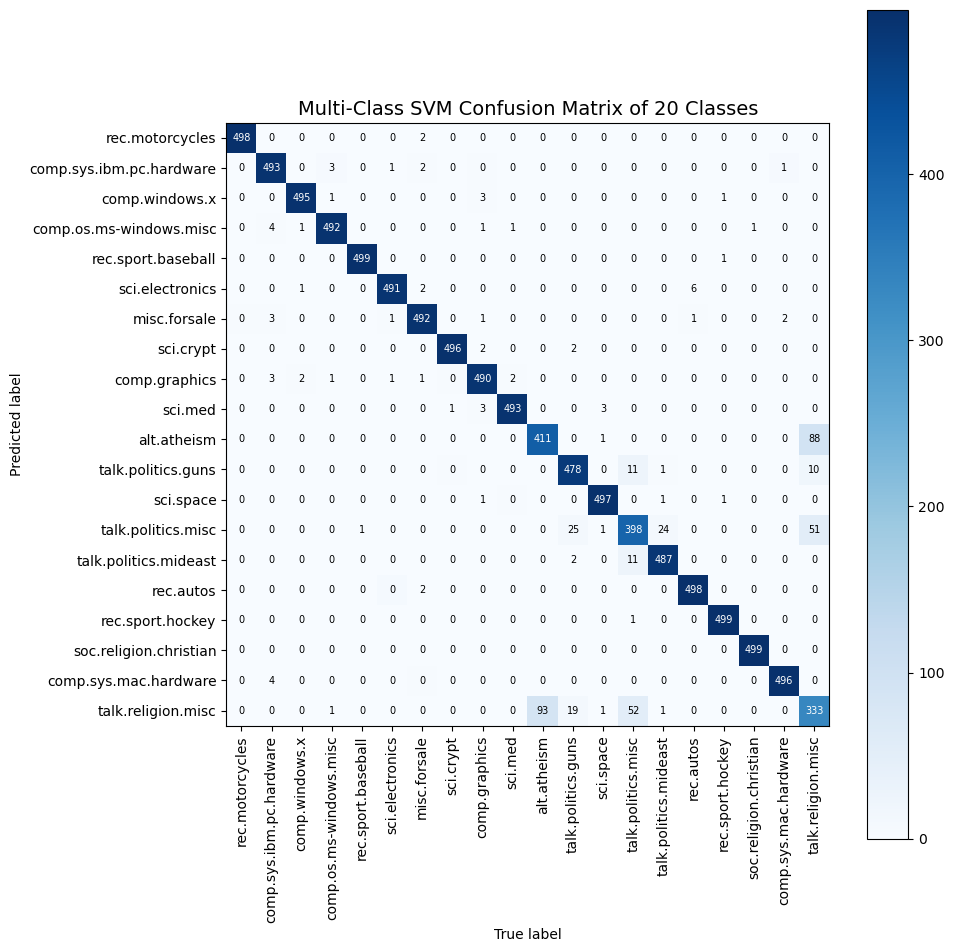

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(confusion_matrix, interpolation='nearest', cmap='Blues')

ax.set_title("Multi-Class SVM Confusion Matrix of 20 Classes", fontsize=14)
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90)
ax.set_yticklabels(classes)

thresh = confusion_matrix.max() / 2.
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        ax.text(i, j, f"{confusion_matrix[i, j]:d}",
                ha="center", va="center",
                color="white" if confusion_matrix[i, j] > thresh else "black",
                fontsize=7)

ax.set_ylabel('Predicted label')
ax.set_xlabel('True label')
plt.tight_layout()
plt.show()